<a href="https://colab.research.google.com/github/RobertoCalber/DataScienceSeminar/blob/main/Laboratorio1_Incremento1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
---
# 📚 MÓDULO B — Fundamentos Conceptuales
### Bodegas de Datos · Modelos Multidimensionales · Estadística · Histogramas · Outliers · Missings
---


# 📚 MÓDULO CONCEPTUAL — Fundamentos de Datos
## Bodegas de Datos · Modelos Multidimensionales · Estadística · Distribuciones · Outliers · Datos Faltantes

> **¿Para qué sirve este módulo?**
> Antes de limpiar o modelar datos, un científico de datos necesita entender
> **cómo están organizados**, **qué forma tienen** y **qué problemas pueden tener**.
> Este módulo te da ese marco conceptual con ejemplos del dataset bancario que ya conoces.

---

### Mapa del módulo

| Sección | Tema |
|---------|------|
| **B1** | Bodegas de Datos — ¿qué son y para qué sirven? |
| **B2** | Modelo Multidimensional — hechos, dimensiones y cubos |
| **B3** | Estadísticos descriptivos — resumir datos en números |
| **B4** | Histogramas y distribuciones — la forma de los datos |
| **B5** | Valores atípicos (outliers) — datos que se salen de lo normal |
| **B6** | Datos desaparecidos (missings) — cuando la información no está |

---


## ⚙️ Configuración inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)

# ── Carga del dataset (ajusta la ruta según tu ambiente) ─────────────
ruta = "/content/drive/MyDrive/Classroom/ET0203 - SEMINARIO DE LA CIENCIA DE LOS DATOS/Notebooks/data/dataset_banco.csv"
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except:
    pass

try:
    data = pd.read_csv(ruta)
    data.columns = data.columns.str.lower().str.strip()
    for col in data.select_dtypes('object').columns:
        data[col] = data[col].str.lower().str.strip()
    data.dropna(inplace=True)
    data.drop_duplicates(inplace=True)
    print(f"✅ Dataset bancario cargado: {data.shape[0]:,} filas × {data.shape[1]} columnas")
except:
    # Dataset de ejemplo si no está disponible el archivo
    np.random.seed(42)
    n = 2000
    data = pd.DataFrame({
        'age'      : np.random.randint(22, 75, n),
        'job'      : np.random.choice(['admin.','blue-collar','management','retired','technician'], n),
        'marital'  : np.random.choice(['married','single','divorced'], n, p=[0.6,0.3,0.1]),
        'education': np.random.choice(['primary','secondary','tertiary','unknown'], n, p=[0.15,0.5,0.3,0.05]),
        'balance'  : np.concatenate([np.random.normal(1400, 3000, n-30),
                                     np.array([50000, 65000, -3000, -4500]*7, dtype=float)[:30]]),
        'duration' : np.abs(np.random.normal(260, 260, n)).astype(int),
        'campaign' : np.random.randint(1, 12, n),
        'pdays'    : np.random.choice([-1, 100, 200, 300], n, p=[0.8, 0.08, 0.07, 0.05]),
        'previous' : np.random.randint(0, 6, n),
        'month'    : np.random.choice(['jan','feb','mar','apr','may','jun',
                                       'jul','aug','sep','oct','nov','dec'], n),
        'y'        : np.random.choice(['yes','no'], n, p=[0.12, 0.88]),
        'default'  : np.random.choice(['yes','no'], n, p=[0.02, 0.98]),
        'housing'  : np.random.choice(['yes','no'], n, p=[0.56, 0.44]),
        'loan'     : np.random.choice(['yes','no'], n, p=[0.16, 0.84]),
    })
    print("⚠️  Dataset de ejemplo generado (archivo original no encontrado)")
    print(f"   Forma: {data.shape}")

data.head(3)


Mounted at /content/drive
✅ Dataset bancario cargado: 45,203 filas × 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.00,yes,no,unknown,5,may,261.00,1,-1.00,0,unknown,no
1,44,technician,single,secondary,no,29.00,yes,no,unknown,5,may,151.00,1,-1.00,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.00,yes,yes,unknown,5,may,76.00,1,-1.00,0,unknown,no


---
## 🏛️ B1. Bodegas de Datos (Data Warehouses)

### ¿Qué es una bodega de datos?

Una **bodega de datos** (Data Warehouse) es un repositorio centralizado que almacena
grandes volúmenes de datos **históricos** e **integrados** de múltiples fuentes,
diseñado específicamente para el análisis y la toma de decisiones.

> **Analogía:** Un supermercado tiene bodegas donde guarda todo su inventario organizado
> para distribución rápida. Una bodega de datos hace lo mismo pero con información.

### Base de datos operacional vs Bodega de datos

| Característica | Base de datos operacional (OLTP) | Bodega de datos (OLAP) |
|---|---|---|
| **Propósito** | Transacciones diarias | Análisis histórico |
| **Ejemplo** | Registrar una venta en tiempo real | Analizar ventas de los últimos 5 años |
| **Operaciones** | INSERT, UPDATE, DELETE | SELECT, GROUP BY, agregaciones |
| **Velocidad** | Muy rápida (milisegundos) | Más lenta (segundos/minutos) |
| **Volumen** | Miles de registros activos | Millones/billones de registros históricos |
| **Usuarios** | Cajeros, empleados, apps | Analistas, gerentes, científicos de datos |
| **Actualización** | Tiempo real | Por lotes (batch), cada hora o cada día |

### En el contexto de nuestro dataset bancario

El archivo `dataset_banco.csv` que estamos usando **proviene de una bodega de datos**
del banco. La empresa de marketing extrajo estos registros históricos para analizarlos.

```
[Sistema CRM del banco]  ──►  [ETL: Extraer-Transformar-Cargar]  ──►  [Bodega de Datos]
 (registra llamadas)           (limpia y transforma)                   (almacena histórico)
                                                                              │
                                                                              ▼
                                                                    [dataset_banco.csv]
                                                                    (lo que usamos hoy)
```

**ETL** = Extract, Transform, Load (Extraer, Transformar, Cargar)
Este proceso es exactamente lo que hemos estado haciendo en el laboratorio.


In [ ]:
# ══ SIMULACIÓN DE FLUJO ETL CON NUESTRO DATASET ════════════════════
# Imaginemos que tenemos datos de TRES fuentes diferentes
# que la bodega de datos integra en una sola tabla

print("=" * 60)
print("SIMULACIÓN DE FLUJO ETL — Dataset Bancario")
print("=" * 60)

# ── FUENTE 1: Sistema CRM (datos del cliente) ────────────────────────
fuente_crm = data[['age', 'job', 'marital', 'education', 'balance', 'default']].copy()
fuente_crm.columns = ['edad', 'trabajo', 'estado_civil', 'educacion', 'saldo', 'incumplimiento']
print(f"\n📁 Fuente 1 — CRM (datos del cliente):    {fuente_crm.shape}")
print(fuente_crm.head(2).to_string())

# ── FUENTE 2: Sistema de Campañas (datos del contacto) ───────────────
fuente_campana = data[['duration', 'campaign', 'pdays', 'previous', 'month']].copy()
fuente_campana.columns = ['duracion_llamada', 'n_contactos', 'dias_desde_contacto',
                           'contactos_previos', 'mes_contacto']
print(f"\n📁 Fuente 2 — Sistema de Campañas:        {fuente_campana.shape}")
print(fuente_campana.head(2).to_string())

# ── FUENTE 3: Resultado (variable objetivo) ───────────────────────────
fuente_resultado = data[['y', 'housing', 'loan']].copy()
fuente_resultado.columns = ['respuesta', 'tiene_hipoteca', 'tiene_prestamo']
print(f"\n📁 Fuente 3 — Resultados de campaña:      {fuente_resultado.shape}")
print(fuente_resultado.head(2).to_string())

# ── INTEGRACIÓN EN LA BODEGA ──────────────────────────────────────────
data_bodega = pd.concat([fuente_crm, fuente_campana, fuente_resultado], axis=1)
print(f"\n🏛️  Tabla integrada en Bodega de Datos:   {data_bodega.shape}")
print(f"   → {data_bodega.shape[1]} columnas desde {3} fuentes distintas")
print(data_bodega.head(2).to_string())


SIMULACIÓN DE FLUJO ETL — Dataset Bancario

📁 Fuente 1 — CRM (datos del cliente):    (45203, 6)
   edad     trabajo estado_civil  educacion   saldo incumplimiento
0    58  management      married   tertiary 2143.00             no
1    44  technician       single  secondary   29.00             no

📁 Fuente 2 — Sistema de Campañas:        (45203, 5)
   duracion_llamada  n_contactos  dias_desde_contacto  contactos_previos mes_contacto
0            261.00            1                -1.00                  0          may
1            151.00            1                -1.00                  0          may

📁 Fuente 3 — Resultados de campaña:      (45203, 3)
  respuesta tiene_hipoteca tiene_prestamo
0        no            yes             no
1        no            yes             no

🏛️  Tabla integrada en Bodega de Datos:   (45203, 14)
   → 14 columnas desde 3 fuentes distintas
   edad     trabajo estado_civil  educacion   saldo incumplimiento  duracion_llamada  n_contactos  dias_desde_conta

---
## 🧊 B2. Modelo de Datos Multidimensional

### La idea central: Hechos y Dimensiones

El modelo multidimensional organiza los datos en dos tipos de tablas:

**HECHOS (Facts):** La medida que queremos analizar — lo que ocurrió.
> Ejemplo: "el cliente X hizo una llamada de 350 segundos en mayo y dijo SÍ"

**DIMENSIONES (Dimensions):** El contexto que describe el hecho — el quién, cuándo, dónde.
> Ejemplo: quién (perfil del cliente), cuándo (mes, día), qué canal (teléfono/celular)

### El esquema Estrella (Star Schema)

```
                    ┌─────────────────┐
                    │  DIM_CLIENTE     │
                    │  - edad          │
                    │  - trabajo       │
                    │  - educación     │
                    │  - estado_civil  │
                    └────────┬────────┘
                             │
 ┌──────────────┐   ┌────────▼────────┐   ┌──────────────────┐
 │  DIM_TIEMPO  │   │   FACT_CAMPAÑA  │   │  DIM_PRODUCTO    │
 │  - mes       ├───►  - duracion     ◄───┤  - tiene_hipoteca│
 │  - dia       │   │  - n_contactos  │   │  - tiene_prestamo│
 └──────────────┘   │  - respuesta ✓  │   └──────────────────┘
                    │  - saldo        │
                    └────────┬────────┘
                             │
                    ┌────────▼────────┐
                    │  DIM_CANAL      │
                    │  - tipo_contacto│
                    │  - resultado_ant│
                    └─────────────────┘
```

La tabla de **HECHOS** está en el centro y se conecta con las **DIMENSIONES** a su alrededor,
formando una estrella. Por eso se llama **Esquema Estrella**.

### ¿Por qué es útil?

Permite responder preguntas de negocio como:
- ¿Cuánto duran las llamadas **por mes** y **por tipo de trabajo**?
- ¿Qué perfil de cliente tiene mayor tasa de conversión **por canal de contacto**?


In [ ]:
# ══ CONSTRUYENDO UN ESQUEMA ESTRELLA CON NUESTROS DATOS ════════════

# ── Tabla de HECHOS ───────────────────────────────────────────────────
fact_campana = data[['duration', 'campaign', 'pdays', 'previous', 'y', 'balance']].copy()
fact_campana.columns = ['duracion_seg', 'n_contactos', 'dias_previos',
                         'contactos_ant', 'convirtio', 'saldo']
fact_campana['convirtio'] = (fact_campana['convirtio'] == 'yes').astype(int)
fact_campana.index.name = 'id_llamada'

# ── Dimensión CLIENTE ─────────────────────────────────────────────────
dim_cliente = data[['age', 'job', 'marital', 'education', 'default']].copy()
dim_cliente.columns = ['edad', 'trabajo', 'estado_civil', 'educacion', 'en_mora']

# ── Dimensión TIEMPO ──────────────────────────────────────────────────
dim_tiempo = data[['month']].copy() if 'month' in data.columns else pd.DataFrame({'mes': ['unknown']*len(data)})
dim_tiempo.columns = ['mes']

# ── Dimensión PRODUCTO (servicios financieros del cliente) ────────────
dim_producto = data[['housing', 'loan']].copy() if 'housing' in data.columns else pd.DataFrame()
if not dim_producto.empty:
    dim_producto.columns = ['tiene_hipoteca', 'tiene_prestamo']

print("ESQUEMA ESTRELLA — Tablas del modelo multidimensional")
print("=" * 55)
print(f"  📊 FACT_CAMPAÑA  : {fact_campana.shape[0]:>6,} filas × {fact_campana.shape[1]} columnas")
print(f"  👤 DIM_CLIENTE   : {dim_cliente.shape[0]:>6,} filas × {dim_cliente.shape[1]} columnas")
print(f"  📅 DIM_TIEMPO    : {dim_tiempo.shape[0]:>6,} filas × {dim_tiempo.shape[1]} columnas")
if not dim_producto.empty:
    print(f"  🏦 DIM_PRODUCTO  : {dim_producto.shape[0]:>6,} filas × {dim_producto.shape[1]} columnas")

print(f"\nVista de FACT_CAMPAÑA:")
print(fact_campana.head(4).to_string())


ESQUEMA ESTRELLA — Tablas del modelo multidimensional
  📊 FACT_CAMPAÑA  : 45,203 filas × 6 columnas
  👤 DIM_CLIENTE   : 45,203 filas × 5 columnas
  📅 DIM_TIEMPO    : 45,203 filas × 1 columnas
  🏦 DIM_PRODUCTO  : 45,203 filas × 2 columnas

Vista de FACT_CAMPAÑA:
            duracion_seg  n_contactos  dias_previos  contactos_ant  convirtio   saldo
id_llamada                                                                           
0                 261.00            1         -1.00              0          0 2143.00
1                 151.00            1         -1.00              0          0   29.00
2                  76.00            1         -1.00              0          0    2.00
3                  92.00            1         -1.00              0          0 1506.00


In [ ]:
# ══ ANÁLISIS MULTIDIMENSIONAL (OLAP) — CONSULTAS TIPO CUBO ════════
# Un "cubo OLAP" permite cortar y rotar los datos en múltiples dimensiones
# Aquí lo simulamos con pandas groupby

print("ANÁLISIS MULTIDIMENSIONAL — Preguntas de negocio")
print("=" * 55)

# Une las tablas (simula un JOIN en SQL / operación de cubo)
data_cubo = pd.concat([fact_campana, dim_cliente, dim_tiempo], axis=1)

# ── CONSULTA 1: Duración promedio por nivel educativo ─────────────────
print("\n📊 CORTE 1: Duración promedio de llamada por educación")
print("   (Dimensión: educación → Medida: duración)")
corte1 = data_cubo.groupby('educacion')['duracion_seg'].agg(['mean','count']).round(1)
corte1.columns = ['Duración_Promedio_seg', 'N_Llamadas']
corte1 = corte1.sort_values('Duración_Promedio_seg', ascending=False)
print(corte1.to_string())

# ── CONSULTA 2: Tasa de conversión por trabajo ────────────────────────
print("\n📊 CORTE 2: Tasa de conversión (%) por tipo de trabajo")
print("   (Dimensión: trabajo → Medida: % que dijo SÍ)")
corte2 = (data_cubo.groupby('trabajo')['convirtio']
          .agg(['mean','count'])
          .rename(columns={'mean':'Tasa_Conversion_%','count':'N_Contactos'}))
corte2['Tasa_Conversion_%'] = (corte2['Tasa_Conversion_%'] * 100).round(1)
corte2 = corte2.sort_values('Tasa_Conversion_%', ascending=False)
print(corte2.head(6).to_string())

# ── CONSULTA 3: Tabla pivote (2 dimensiones) ──────────────────────────
print("\n📊 CORTE 3: % conversión por educación × estado civil")
print("   (2 dimensiones simultáneas — tabla pivote)")
pivot = data_cubo.pivot_table(
    values='convirtio',
    index='educacion',
    columns='estado_civil',
    aggfunc='mean'
) * 100
print(pivot.round(1).to_string())
print("\n   → Cada celda = % de clientes que dijeron SÍ")


ANÁLISIS MULTIDIMENSIONAL — Preguntas de negocio

📊 CORTE 1: Duración promedio de llamada por educación
   (Dimensión: educación → Medida: duración)
           Duración_Promedio_seg  N_Llamadas
educacion                                   
sec.                      360.00           2
secondary                 258.60       23194
tertiary                  258.40       13300
unknown                   257.40        1855
primary                   255.70        6850
unk                       217.00           2

📊 CORTE 2: Tasa de conversión (%) por tipo de trabajo
   (Dimensión: trabajo → Medida: % que dijo SÍ)
            Tasa_Conversion_%  N_Contactos
trabajo                                   
student                 28.70          938
retired                 22.80         2264
unemployed              15.50         1303
management              13.70         9457
admin.                  12.20         5166
unknown                 11.80          288

📊 CORTE 3: % conversión por educación × est

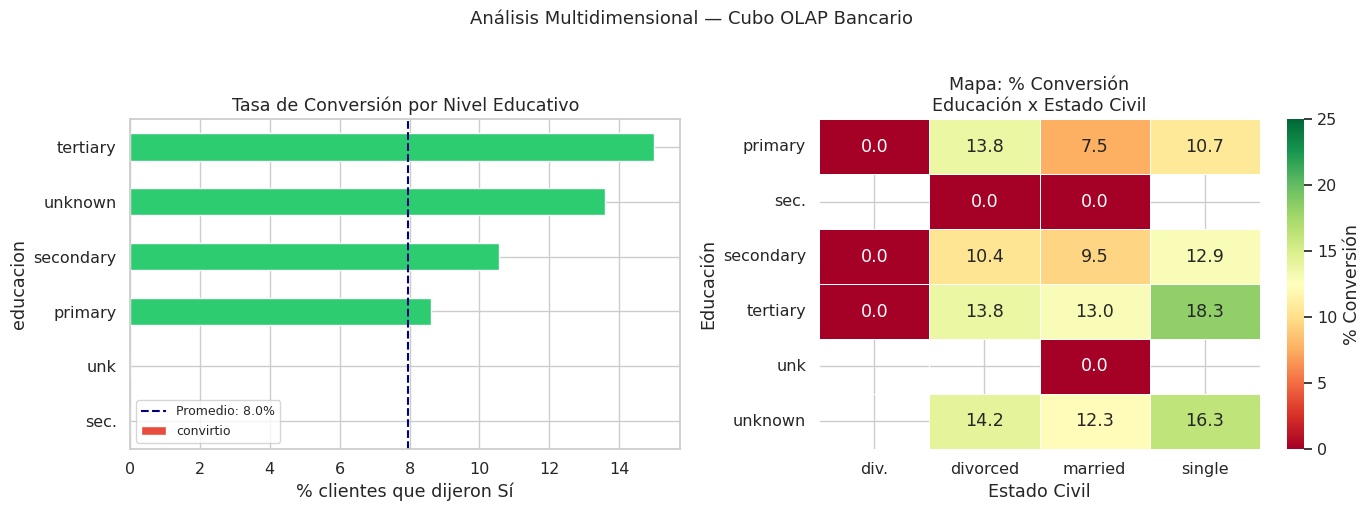

💡 Lectura: Verde = mayor conversión | Rojo = menor conversión
   El cruce de dimensiones revela segmentos con mayor potencial.


In [ ]:
# ══ VISUALIZACIÓN DEL CUBO OLAP ════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análisis Multidimensional — Cubo OLAP Bancario", fontsize=13, y=1.02)

# Gráfico 1: Tasa de conversión por educación
conv_edu = (data_cubo.groupby('educacion')['convirtio'].mean() * 100).sort_values(ascending=True)
colores = ['#e74c3c' if v < conv_edu.mean() else '#2ecc71' for v in conv_edu]
conv_edu.plot(kind='barh', ax=axes[0], color=colores, edgecolor='white')
axes[0].axvline(conv_edu.mean(), color='navy', linestyle='--', linewidth=1.5,
                label=f'Promedio: {conv_edu.mean():.1f}%')
axes[0].set_title("Tasa de Conversión por Nivel Educativo")
axes[0].set_xlabel("% clientes que dijeron Sí")
axes[0].legend(fontsize=9)

# Gráfico 2: Heatmap tasa de conversión (2 dimensiones)
pivot_heat = data_cubo.pivot_table(
    values='convirtio', index='educacion', columns='estado_civil', aggfunc='mean'
) * 100
sns.heatmap(pivot_heat, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5, vmin=0, vmax=25,
            cbar_kws={'label': '% Conversión'})
axes[1].set_title("Mapa: % Conversión\nEducación x Estado Civil")
axes[1].set_xlabel("Estado Civil")
axes[1].set_ylabel("Educación")

plt.tight_layout()
plt.show()

print("💡 Lectura: Verde = mayor conversión | Rojo = menor conversión")
print("   El cruce de dimensiones revela segmentos con mayor potencial.")


### Incremento 2

In [ ]:
# ══ CÁLCULO MANUAL Y CON PANDAS ════════════════════════════════════

variable = data['balance'] if 'balance' in data.columns else data['age']
nombre_var = 'balance' if 'balance' in data.columns else 'age'

print(f"ESTADÍSTICOS DESCRIPTIVOS — Variable: '{nombre_var}'")
print("=" * 55)

# ── Tendencia central ─────────────────────────────────────────────────
media    = variable.mean()
mediana  = variable.median()
moda     = variable.mode()[0]

print("\n📍 TENDENCIA CENTRAL:")
print(f"   Media          : {media:>10.2f}  ← promedio de todos los valores")
print(f"   Mediana        : {mediana:>10.2f}  ← valor del medio (50% abajo, 50% arriba)")
print(f"   Moda           : {moda:>10.2f}  ← valor más frecuente")
print(f"   → Media {'>' if media > mediana else '<'} Mediana: distribución {'sesgada a la derecha 📈' if media > mediana else 'sesgada a la izquierda 📉'}")

# ── Dispersión ────────────────────────────────────────────────────────
std     = variable.std()
varianza= variable.var()
rango   = variable.max() - variable.min()
q1      = variable.quantile(0.25)
q3      = variable.quantile(0.75)
iqr     = q3 - q1
cv      = (std / abs(media)) * 100

print("\n📐 DISPERSIÓN:")
print(f"   Desv. Estándar : {std:>10.2f}  ← alejamiento promedio de la media")
print(f"   Varianza       : {varianza:>10.2f}  ← desv. estándar al cuadrado")
print(f"   Rango          : {rango:>10.2f}  ← máximo - mínimo")
print(f"   IQR (Q3-Q1)    : {iqr:>10.2f}  ← rango del 50% central (robusto)")
print(f"   Coef. Variación: {cv:>9.1f}%  ← dispersión relativa")

# ── Posición ──────────────────────────────────────────────────────────
print("\n📊 POSICIÓN (Percentiles / Cuartiles):")
for p in [5, 25, 50, 75, 95]:
    val = variable.quantile(p/100)
    print(f"   Percentil {p:>2}° : {val:>10.2f}  ← {p}% de los datos están por debajo")


ESTADÍSTICOS DESCRIPTIVOS — Variable: 'balance'

📍 TENDENCIA CENTRAL:
   Media          :    1373.89  ← promedio de todos los valores
   Mediana        :     448.00  ← valor del medio (50% abajo, 50% arriba)
   Moda           :       0.00  ← valor más frecuente
   → Media > Mediana: distribución sesgada a la derecha 📈

📐 DISPERSIÓN:
   Desv. Estándar :    3923.85  ← alejamiento promedio de la media
   Varianza       : 15396615.19  ← desv. estándar al cuadrado
   Rango          :  535551.00  ← máximo - mínimo
   IQR (Q3-Q1)    :    1355.50  ← rango del 50% central (robusto)
   Coef. Variación:     285.6%  ← dispersión relativa

📊 POSICIÓN (Percentiles / Cuartiles):
   Percentil  5° :    -172.00  ← 5% de los datos están por debajo
   Percentil 25° :      72.00  ← 25% de los datos están por debajo
   Percentil 50° :     448.00  ← 50% de los datos están por debajo
   Percentil 75° :    1427.50  ← 75% de los datos están por debajo
   Percentil 95° :    5768.90  ← 95% de los datos están por 

In [ ]:
# ══ COMPARACIÓN: MEDIA VS MEDIANA — IMPACTO DE OUTLIERS ════════════

print("EXPERIMENTO: ¿Qué pasa con la media cuando hay outliers?")
print("=" * 55)

saldo = data['balance'].copy() if 'balance' in data.columns else data['age'].copy()
nombre = 'balance' if 'balance' in data.columns else 'age'

# Dataset original
media_orig   = saldo.mean()
mediana_orig = saldo.median()
print(f"\n📊 Dataset original ({len(saldo):,} registros):")
print(f"   Media   = {media_orig:.2f}")
print(f"   Mediana = {mediana_orig:.2f}")

# Agregar 5 valores extremos artificiales
saldo_con_outliers = pd.concat([saldo, pd.Series([500000, 600000, 700000, 800000, 900000])])
media_out   = saldo_con_outliers.mean()
mediana_out = saldo_con_outliers.median()

print(f"\n⚠️  Con 5 valores extremos agregados ({len(saldo_con_outliers):,} registros):")
print(f"   Media   = {media_out:.2f}   (cambió {media_out - media_orig:+.2f})")
print(f"   Mediana = {mediana_out:.2f}   (cambió {mediana_out - mediana_orig:+.2f})")

print(f"\n💡 Conclusión:")
print(f"   La MEDIA cambió {abs(media_out - media_orig):.0f} unidades por solo 5 outliers")
print(f"   La MEDIANA solo cambió {abs(mediana_out - mediana_orig):.2f} unidades")
print(f"   → La mediana es ROBUSTA ante valores extremos")
print(f"   → Usar mediana cuando hay outliers o distribución sesgada")


EXPERIMENTO: ¿Qué pasa con la media cuando hay outliers?

📊 Dataset original (45,203 registros):
   Media   = 1373.89
   Mediana = 448.00

⚠️  Con 5 valores extremos agregados (45,208 registros):
   Media   = 1451.16   (cambió +77.27)
   Mediana = 448.00   (cambió +0.00)

💡 Conclusión:
   La MEDIA cambió 77 unidades por solo 5 outliers
   La MEDIANA solo cambió 0.00 unidades
   → La mediana es ROBUSTA ante valores extremos
   → Usar mediana cuando hay outliers o distribución sesgada


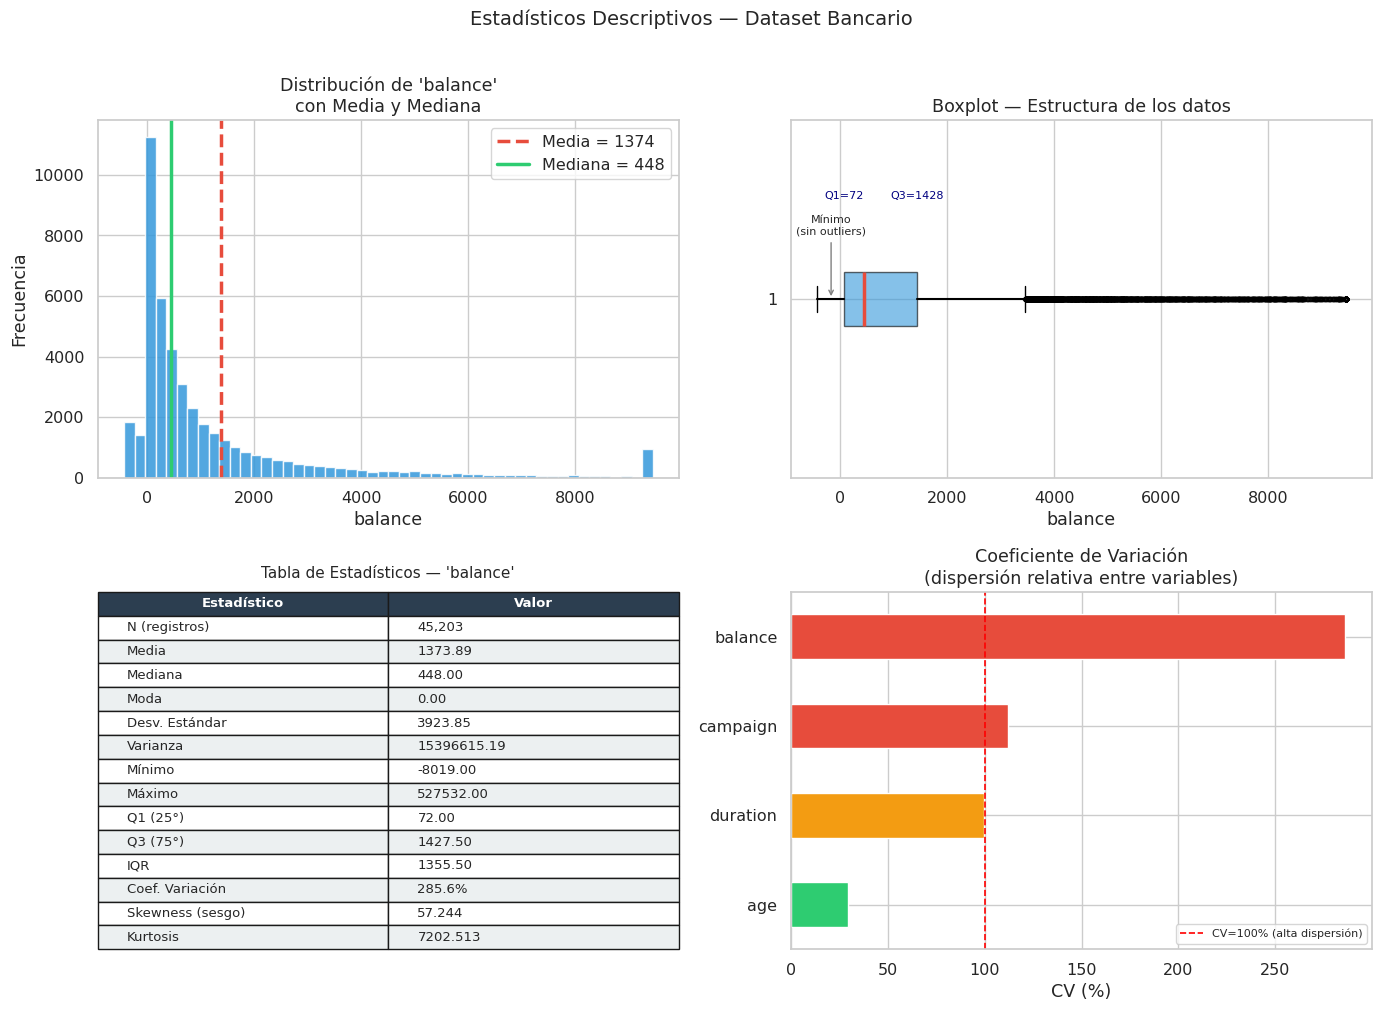

In [ ]:
# ══ VISUALIZACIÓN COMPLETA DE ESTADÍSTICOS ══════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Estadísticos Descriptivos — Dataset Bancario", fontsize=14, y=1.01)

variable_plot = data['balance'] if 'balance' in data.columns else data['age']
var_name = 'balance' if 'balance' in data.columns else 'age'

media   = variable_plot.mean()
mediana = variable_plot.median()
std     = variable_plot.std()
q1      = variable_plot.quantile(0.25)
q3      = variable_plot.quantile(0.75)

# ─── Gráfico 1: Histograma con media y mediana ───────────────────────
ax = axes[0, 0]
var_clip = variable_plot.clip(variable_plot.quantile(0.02),
                              variable_plot.quantile(0.98))

ax.hist(var_clip, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(media,   color='#e74c3c', linewidth=2.5, linestyle='--',
           label=f'Media = {media:.0f}')
ax.axvline(mediana, color='#2ecc71', linewidth=2.5, linestyle='-',
           label=f'Mediana = {mediana:.0f}')

ax.set_title(f"Distribución de '{var_name}'\ncon Media y Mediana")
ax.set_xlabel(var_name)
ax.set_ylabel("Frecuencia")
ax.legend()

# ─── Gráfico 2: Boxplot con anotaciones ─────────────────────────────
ax = axes[0, 1]

bp = ax.boxplot(var_clip, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6),
                medianprops=dict(color='#e74c3c', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))

ax.set_title("Boxplot — Estructura de los datos")
ax.set_xlabel(var_name)

# Anotaciones
y_pos = 1.18

ax.annotate('Mínimo\n(sin outliers)',
            xy=(variable_plot.quantile(0.05), 1),
            xytext=(variable_plot.quantile(0.05), y_pos),
            ha='center', fontsize=8,
            arrowprops=dict(arrowstyle='->', color='gray'))

ax.annotate(f'Q1={q1:.0f}',
            xy=(q1, 1),
            xytext=(q1, y_pos+0.1),
            ha='center', fontsize=8, color='navy')

ax.annotate(f'Q3={q3:.0f}',
            xy=(q3, 1),
            xytext=(q3, y_pos+0.1),
            ha='center', fontsize=8, color='navy')

# ─── Gráfico 3: Tabla de estadísticos visualizada ────────────────────
ax = axes[1, 0]
ax.axis('off')

estadisticos = {
    'N (registros)'         : f"{len(variable_plot):,}",
    'Media'                 : f"{media:.2f}",
    'Mediana'               : f"{mediana:.2f}",
    'Moda'                  : f"{variable_plot.mode()[0]:.2f}",
    'Desv. Estándar'        : f"{std:.2f}",
    'Varianza'              : f"{variable_plot.var():.2f}",
    'Mínimo'                : f"{variable_plot.min():.2f}",
    'Máximo'                : f"{variable_plot.max():.2f}",
    'Q1 (25°)'              : f"{q1:.2f}",
    'Q3 (75°)'              : f"{q3:.2f}",
    'IQR'                   : f"{q3-q1:.2f}",
    'Coef. Variación'       : f"{std/abs(media)*100:.1f}%",
    'Skewness (sesgo)'      : f"{variable_plot.skew():.3f}",
    'Kurtosis'              : f"{variable_plot.kurt():.3f}",
}

tabla = pd.DataFrame(list(estadisticos.items()),
                     columns=['Estadístico', 'Valor'])

tbl = ax.table(cellText=tabla.values,
               colLabels=tabla.columns,
               cellLoc='left',
               loc='center',
               bbox=[0, 0, 1, 1])

tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

for j in range(2):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(tabla)+1):
    color = '#ecf0f1' if i % 2 == 0 else 'white'
    for j in range(2):
        tbl[i, j].set_facecolor(color)

ax.set_title(f"Tabla de Estadísticos — '{var_name}'", fontsize=11, pad=10)

# ─── Gráfico 4: Comparación de dispersión ────────────────────────────
ax = axes[1, 1]

vars_num = [c for c in ['age','balance','duration','campaign']
            if c in data.columns][:4]

cvs = {col: (data[col].std() / abs(data[col].mean()) * 100)
       for col in vars_num}

cv_series = pd.Series(cvs).sort_values(ascending=True)

colors = ['#e74c3c' if v > 100 else '#f39c12' if v > 50 else '#2ecc71'
          for v in cv_series]

cv_series.plot(kind='barh', ax=ax,
               color=colors, edgecolor='white')

ax.axvline(100, color='red', linestyle='--',
           linewidth=1.2, label='CV=100% (alta dispersión)')

ax.set_title("Coeficiente de Variación\n(dispersión relativa entre variables)")
ax.set_xlabel("CV (%)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

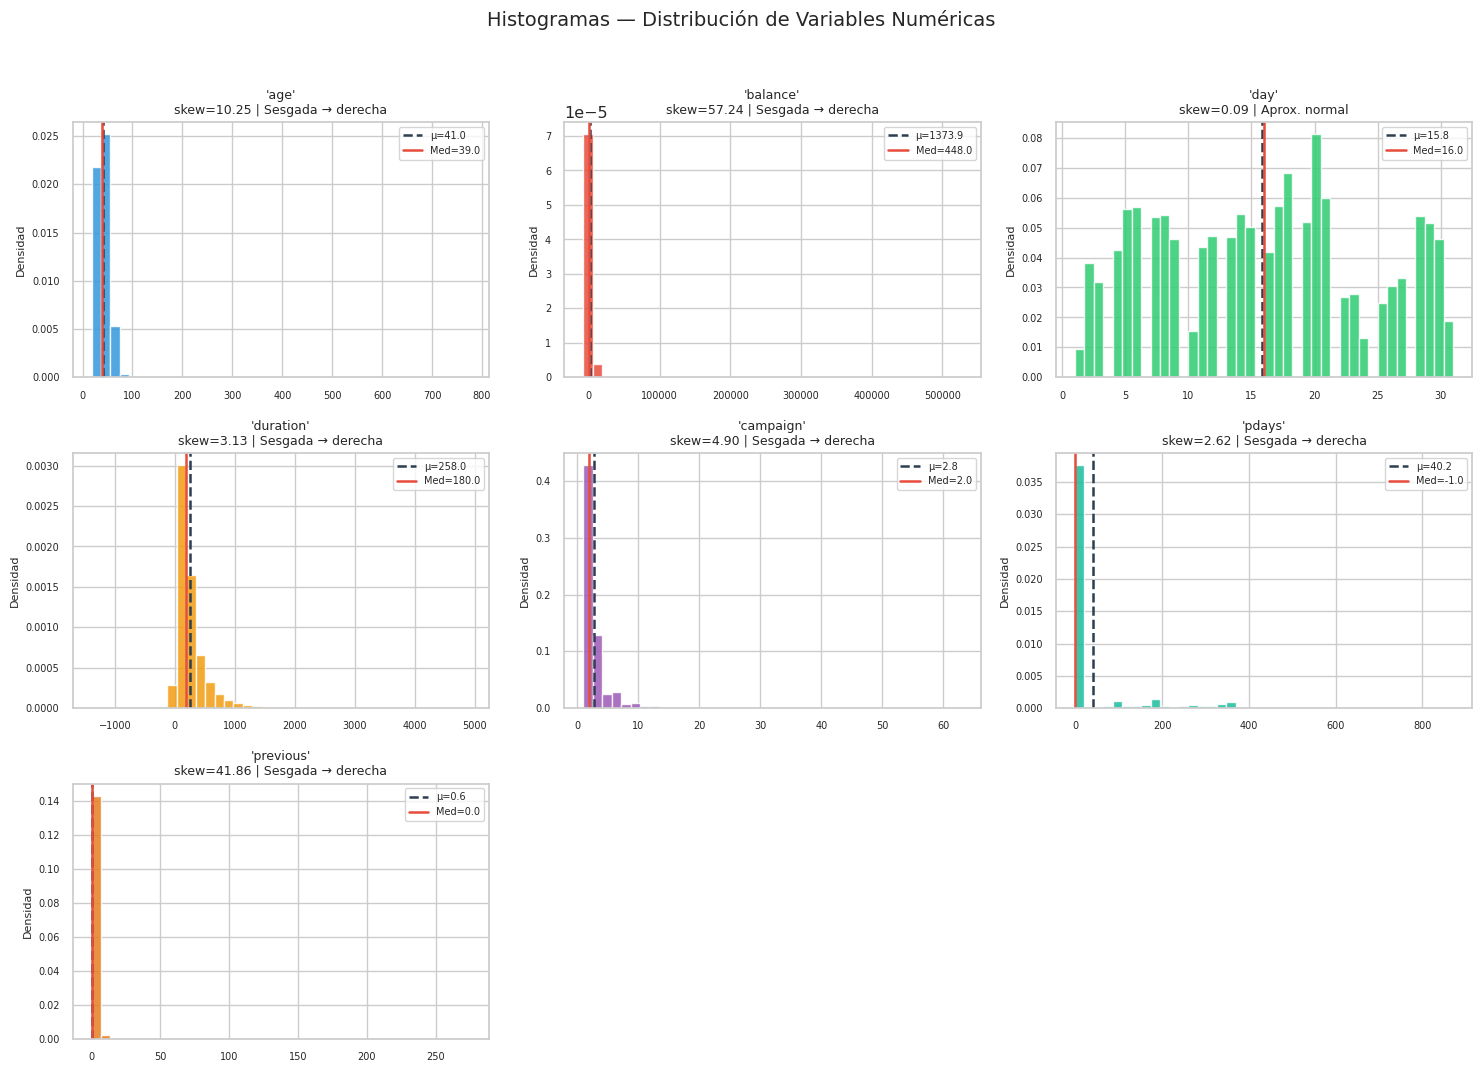

In [ ]:
# ══ HISTOGRAMAS DE TODAS LAS VARIABLES NUMÉRICAS ═══════════════════

import numpy as np

# Selección de variables numéricas excluyendo variable objetivo binaria
vars_num = [c for c in data.select_dtypes(include=[np.number]).columns
            if c not in ['y_bin']]

# Validación
if len(vars_num) == 0:
    print("No hay variables numéricas para graficar.")
else:

    n_vars = len(vars_num)
    ncols  = 3
    nrows  = int(np.ceil(n_vars / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
    fig.suptitle("Histogramas — Distribución de Variables Numéricas",
                 fontsize=14, y=1.02)

    # Asegurar que axes siempre sea iterable
    if isinstance(axes, np.ndarray):
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    COLORES = ['#3498db','#e74c3c','#2ecc71',
               '#f39c12','#9b59b6','#1abc9c','#e67e22']

    for i, col in enumerate(vars_num):
        ax = axes_flat[i]

        serie = data[col].dropna()

        if len(serie) == 0:
            ax.set_visible(False)
            continue

        media   = serie.mean()
        mediana = serie.median()
        skew    = serie.skew()

        ax.hist(serie, bins=40,
                color=COLORES[i % len(COLORES)],
                edgecolor='white',
                alpha=0.85,
                density=True)

        ax.axvline(media,   color='#2c3e50',
                   linestyle='--', lw=1.8,
                   label=f'μ={media:.1f}')

        ax.axvline(mediana, color='#e74c3c',
                   linestyle='-', lw=1.8,
                   label=f'Med={mediana:.1f}')

        # Clasificación del sesgo
        if abs(skew) < 0.5:
            forma = "Aprox. normal"
        elif skew > 0.5:
            forma = "Sesgada → derecha"
        else:
            forma = "Sesgada ← izquierda"

        ax.set_title(f"'{col}'\nskew={skew:.2f} | {forma}",
                     fontsize=9)

        ax.set_ylabel("Densidad", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)

    # Ocultar subplots vacíos
    for j in range(len(vars_num), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()